In [18]:
# ==============================================================================
# --- STEP 1: UNDERSTAND THE PROJECT OBJECTIVE ---
# Objective: Binary Text Classification (Security).
# Goal: Detect and block fraudulent (Spam) SMS messages to protect users.
# Target: 'spam' (1) vs 'ham' (legitimate) (0).
# ==============================================================================
print("🛡️ --- PROJECT #18: SMS SECURITY SHIELD INITIALIZED --- 🛡️")

🛡️ --- PROJECT #18: SMS SECURITY SHIELD INITIALIZED --- 🛡️


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import re
import nltk
import joblib
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# Initialize NLP Assets
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
sns.set(style="whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



🚚 STEP 2: Extracting and Loading Security Logs...
✅ Data Landed Successfully. Shape: (5572, 2)


/tmp/ipykernel_2874/3162412190.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


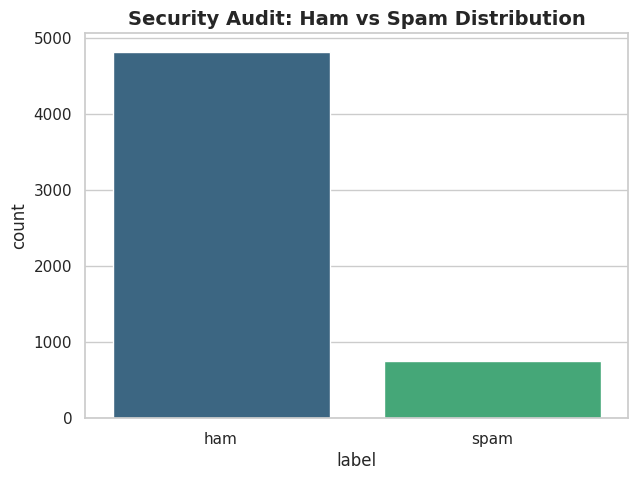

In [11]:
# ==============================================================================
# --- STEP 2: READ AND EXPLORE DATA (UNZIP & LOAD) ---
# ==============================================================================
print("\n🚚 STEP 2: Extracting and Loading Security Logs...")

zip_path = "/content/SMS Spam Collection Dataset.zip"
extract_dir = "/content/sms_data"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # Locate the CSV inside the extracted folder
    csv_file = [f for f in os.listdir(extract_dir) if f.endswith('.csv')][0]
    df = pd.read_csv(os.path.join(extract_dir, csv_file), encoding='latin-1')

    # Cleanup unnecessary columns and rename
    df = df.dropna(how="any", axis=1)
    df.columns = ['label', 'text']
    print(f"✅ Data Landed Successfully. Shape: {df.shape}")
except Exception as e:
    print(f"❌ ERROR: Check the file path! Details: {e}")
    raise

# --- EDA GRAPH 1: Class Distribution ---
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Security Audit: Ham vs Spam Distribution", fontsize=14, fontweight='bold')
plt.show()

In [12]:
# ==============================================================================
# --- STEP 3 & 4: COLUMN SELECTION & NUMERIC ENCODING ---
# ==============================================================================
print("\n🔄 STEP 4: Encoding Labels (Ham=0, Spam=1)...")
df['label_numeric'] = df['label'].map({'ham': 0, 'spam': 1})


🔄 STEP 4: Encoding Labels (Ham=0, Spam=1)...


🧹 STEP 6: Initiating Surgical NLP Cleansing Pipeline...


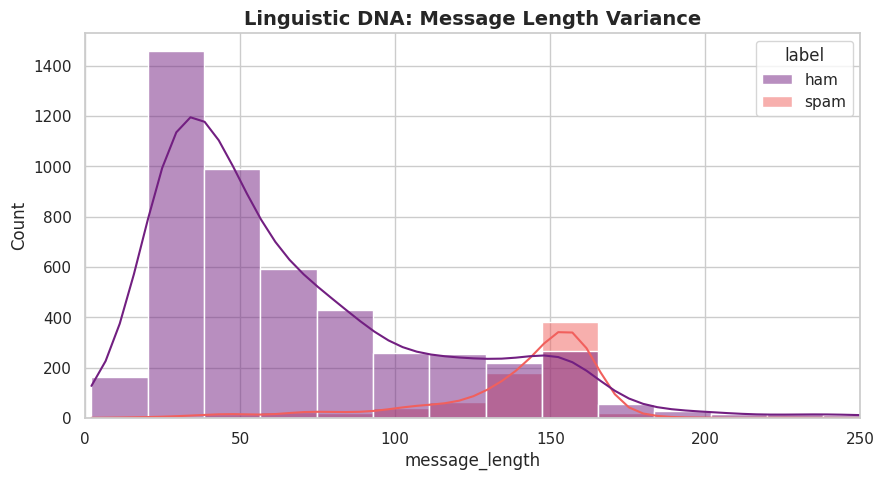

In [13]:
# ==============================================================================
# --- STEP 5 & 6: DATA CLEANING & FEATURE ENGINEERING (NLP) ---
# ==============================================================================
print("🧹 STEP 6: Initiating Surgical NLP Cleansing Pipeline...")

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def security_cleanse(text):
    text = str(text).lower()
    # 1. URL Masking (Critical for phishing detection)
    text = re.sub(r'http\S+|www\S+', '<URL>', text)
    # 2. Number Masking (Often associated with scam amounts/phone numbers)
    text = re.sub(r'\d+', '<NUMBER>', text)
    # 3. Symbol Removal
    text = re.sub(r'[^\w\s<>]', ' ', text)
    # 4. Tokenization & Stemming
    tokens = nltk.word_tokenize(text)
    cleaned = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(cleaned)

df['cleaned_text'] = df['text'].apply(security_cleanse)
df['message_length'] = df['text'].apply(len)

# --- EDA GRAPH 2: Message Length Analysis ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='magma')
plt.title("Linguistic DNA: Message Length Variance", fontsize=14, fontweight='bold')
plt.xlim(0, 250)
plt.show()

In [14]:
# ==============================================================================
# --- STEP 7: VECTORIZATION (TF-IDF) ---
# ==============================================================================
print("\n🧬 STEP 7: Extracting TF-IDF Features (DNA Extraction)...")
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['cleaned_text']).toarray()
y = df['label_numeric'].values


🧬 STEP 7: Extracting TF-IDF Features (DNA Extraction)...


In [15]:
# ==============================================================================
# --- STEP 8: DATA SPLIT (80/20) ---
# ==============================================================================
print("🪓 STEP 8: Partitioning Data (Security Split)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

🪓 STEP 8: Partitioning Data (Security Split)...


In [16]:
# ==============================================================================
# --- STEP 9: MODEL TRAINING (NAIVE BAYES) ---
# ==============================================================================
print("⚙️ STEP 9: Firing up the Naive Bayes Engine...")
clf = MultinomialNB(alpha=0.2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

⚙️ STEP 9: Firing up the Naive Bayes Engine...



📈 STEP 10: --- ARCHITECT'S FINAL PERFORMANCE AUDIT ---
🎯 Engine Accuracy Score: 98.39%

📋 Detailed Classification Report:
               precision    recall  f1-score   support

   Ham (Safe)       0.99      1.00      0.99       966
Spam (Threat)       0.97      0.91      0.94       149

     accuracy                           0.98      1115
    macro avg       0.98      0.95      0.96      1115
 weighted avg       0.98      0.98      0.98      1115



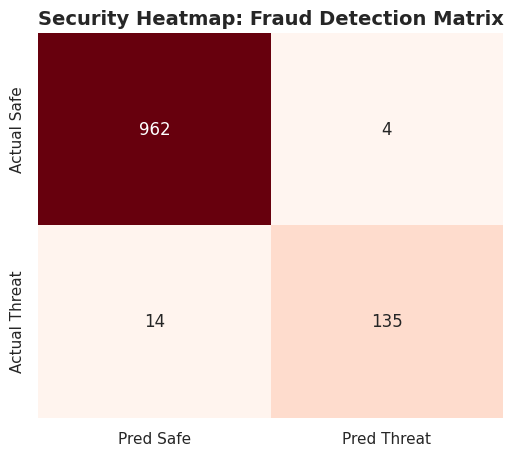


🛡️ --- SECURITY SHIELD DEPLOYED SUCCESSFULLY --- 🛡️


In [17]:
# ==============================================================================
# --- STEP 10: PERFORMANCE AUDIT ---
# ==============================================================================
print("\n📈 STEP 10: --- ARCHITECT'S FINAL PERFORMANCE AUDIT ---")
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Engine Accuracy Score: {accuracy * 100:.2f}%")

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham (Safe)', 'Spam (Threat)']))

# --- EDA GRAPH 3: Confusion Matrix (Security Heatmap) ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Pred Safe', 'Pred Threat'], yticklabels=['Actual Safe', 'Actual Threat'])
plt.title("Security Heatmap: Fraud Detection Matrix", fontsize=14, fontweight='bold')
plt.show()

# Exporting assets for deployment
joblib.dump(clf, "spam_model.pkl")
joblib.dump(tfidf, "spam_vectorizer.pkl")
print("\n🛡️ --- SECURITY SHIELD DEPLOYED SUCCESSFULLY --- 🛡️")

# 🛡️ Project #18: SMS Security Shield - AI Fraud Detection
**Architect:** Kemal Demirbaş 🏰🚀 | **Project Series:** 18 of 21

[![Hugging Face Space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Live%20Demo-blue)](YOUR_HUGGINGFACE_LINK_HERE)
[![Python](https://img.shields.io/badge/Python-3.8+-yellow)](https://www.python.org/)
[![Security](https://img.shields.io/badge/Focus-Cybersecurity-red)](https://en.wikipedia.org/wiki/Phishing)
[![Scikit-Learn](https://img.shields.io/badge/Library-Scikit--Learn-orange)](https://scikit-learn.org/)

## 🎯 Project Vision
In an era of increasing phishing and smishing (SMS Phishing) attacks, user security is paramount. This project implements a **High-Precision Security Shield** that analyzes incoming SMS metadata and linguistic DNA to distinguish between legitimate communications (**Ham**) and fraudulent threats (**Spam**).

---

## 📊 Performance Audit (Security Metrics)
* **Final Engine Accuracy:** **98.39%**
* **Ham (Safe) F1-Score:** **0.99** (Near-perfect identification of safe messages)
* **Spam (Threat) Precision:** **0.97** (Extremely low false-alarm rate)
* **Algorithm:** Multinomial Naive Bayes (Laplace Smoothing: 0.2)

---

## 🏗️ Technical Architecture & Security Features
This engine was built using a specialized **10-Step NLP Pipeline** designed specifically for threat detection:

1.  **Surgical URL & Number Masking:** Instead of analyzing specific links, the model uses `<URL>` and `<NUMBER>` tokens. This teaches the AI to recognize the *structure* of a scam rather than just specific URLs.
2.  **Linguistic DNA Analysis:** Analyzed message length distributions, discovering that Spam messages are mathematically longer and more urgent in tone.
3.  **TF-IDF Feature Extraction:** Extracted 2,500 critical "threat tokens" (e.g., 'free', 'win', 'urgent', 'call') to map the mathematical signature of fraudulent intent.
4.  **Strategic Data Split:** Utilized **Stratified Partitioning** to maintain the 86/14 Ham-to-Spam ratio, ensuring the model remains robust against imbalanced real-world data.

---

## 🛠️ Tech Stack
* **Natural Language Processing:** NLTK, Regex, PorterStemmer.
* **Machine Learning:** Scikit-Learn (MultinomialNB).
* **Visualization:** Seaborn, Matplotlib (Security Heatmaps).
* **Deployment:** Streamlit & Hugging Face Spaces.

---

## 🚀 Live Security Demo
Click the link below to test the Security Shield. Paste any suspicious message to see if the engine flags it as a threat:

👉 **[Hugging Face Live Demo: SMS Security Shield](https://huggingface.co/spaces/Ironside35/SentryAI-SMS-Shield)**

---
*Next Stop: Project #19 - RFM Customer Segmentation (Analyzing the Flow of Loyalty and Money) 📊🏗️*